# 11 — CG-Based Long-Short Portfolios

Quintile portfolios formed annually on CG scores, held one year, evaluated against
FF5+MOM. Primary interest is the **sub-index-level** results — the composite (equal-weight
mean of the six sub-indices) is reported as a summary line, not as a latent factor (see
`07_index_validation.ipynb` §3.3: PC1 explains only ~21% of variance with mixed-sign
loadings, so there is no dominant governance-quality factor to extract). **No PC1
portfolio is built.**

**Formation rule, and why it uses `FY(Y-1)` not `FY(Y)`:** for a formation date of June
30, year Y, `CG_t` is the simple mean of the four `FY(Y-1)` quarterly scores (e.g. formation
in June 2023 uses FY22 = Apr 2021–Mar 2022). This looks like an extra year of lag versus
using the fiscal year that just ended (`FY(Y)`, e.g. FY23 for a 2023 formation) — but it
isn't a typo. Checked empirically against `filing_dates_db.csv`: Q4 (Jan–Mar) CG filings are
**essentially never** filed by June 28 of the same calendar year (median filing lag is
mid-to-late July, sometimes October), so `FY(Y)` is never fully observable at a June 30
formation date. `FY(Y-1)`, by contrast, is **100% observable** (verified: every
FY22/FY23/FY24 filing predates its respective June 28 cutoff by a wide margin) — it's the
most recent fiscal year that's actually complete and public by formation time. The
2-trading-day buffer from the framing decision is applied as
`max(Filing_Date) ≤ (formation date − 2 td)` for precision, though it's not binding given
the year of headroom.

**Design choices:**
- **Formation years**: 2023, 2024, 2025 → holding periods Jul 2023–Jun 2024, Jul
  2024–Jun 2025, Jul 2025–Jun 2026 (the last one's final 2 months lack FF5+MOM factor
  coverage — `ff5mom_factors_monthly.csv` ends 2026-04 — handled by an inner join, not
  silently padded).
- **Weighting**: value-weighted by market cap at formation (Q4 of the FY(Y-1) used for
  `CG_t`), fixed for the full 12-month hold (buy-and-hold, no monthly re-weighting — the
  standard Fama-French-style convention).
- **Evaluation**: all 3 formation years' monthly returns are pooled per quintile into one
  ~34-month calendar-time series before the factor regression (12 months/year gives far too
  few degrees of freedom on its own).
- **Multiple testing**: Romano-Wolf (moving-block bootstrap, block=6 months, B=2,000)
  across the 6 sub-indices' long-short alpha tests. The composite is reported as a
  reference row, not included in the corrected family (per your instruction — it's a
  summary convenience, not a hypothesis on equal footing with the six sub-indices).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import statsmodels.api as sm
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path.cwd()
RAW  = BASE / 'data' / 'raw'
PROC = BASE / 'data' / 'processed'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid')

RF_ANNUAL, RF_MONTHLY = 0.065, 0.065 / 12
FACTOR_COLS = ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
CG_CATS = ['AINDEX', 'BINDEX', 'CINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']
FORMATION_YEARS = [2023, 2024, 2025]
N_QUINTILES = 5
TC_ROUNDTRIP = 0.0030   # 30 bps round-trip cost per rebalance, applied to the long-short leg
RW_B = 2000
RW_BLOCK_LEN = 6        # months, moving-block bootstrap

print(f'Formation years: {FORMATION_YEARS}')
print(f'Transaction cost: {TC_ROUNDTRIP:.2%} round-trip per rebalance')

Formation years: [2023, 2024, 2025]
Transaction cost: 0.30% round-trip per rebalance


## 1 — `CG_t` construction and observability check

For formation year Y, `CG_t` = mean `Avg_Score` across firm i's four `FY(Y-1)` quarters
(mean composite, or a single sub-index). The observability filter drops any quarter whose
`Filing_Date` falls after (formation date − 2 trading days) — verified below to be a no-op
in practice, since `FY(Y-1)` is always fully filed with a year to spare.

In [2]:
scores = pd.read_csv(PROC / 'cg_scores.csv')
scores['BSE Code'] = pd.to_numeric(scores['BSE Code'], errors='coerce')

fdb = pd.read_csv(PROC / 'filing_dates_db.csv')
fdb['BSE_Code'] = pd.to_numeric(fdb['BSE_Code'], errors='coerce')
fdb['Filing_Date'] = pd.to_datetime(fdb['Filing_Date'])

ctrl = pd.read_csv(PROC / 'controls_quarterly.csv')
ctrl['BSE Code'] = pd.to_numeric(ctrl['BSE Code'], errors='coerce')

imap = pd.read_excel(PROC / 'industry_map.xlsx')[['BSE Code', 'NSE Symbol']].dropna()
imap['BSE Code'] = pd.to_numeric(imap['BSE Code'], errors='coerce')


def cg_t_for_year(Y, cat=None, quarter='all'):
    """CG_t for formation year Y, sourced from FY(Y-1)'s quarters.
    cat=None -> mean composite across the 6 sub-indices; cat='AINDEX' etc -> that sub-index only.
    quarter='all' -> mean of available quarters; quarter='Q4' -> Q4(Y-1) score only (robustness)."""
    prior_fy = f'FY{str(Y - 1)[2:]}'
    quarters = [f'Q{q}{prior_fy}' for q in (range(1, 5) if quarter == 'all' else [4])]
    cutoff = pd.Timestamp(f'{Y}-06-30') - pd.Timedelta(days=3)  # ~2 trading days before formation

    # One row per (firm, quarter): a quarter is observable if its EARLIEST filing
    # (across any duplicate filing_dates_db rows) clears the cutoff.
    observable = (fdb[(fdb['Q_FY'].isin(quarters)) & (fdb['Filing_Date'] <= cutoff)]
                  .groupby(['BSE_Code', 'Q_FY'], as_index=False)['Filing_Date'].min()
                  .rename(columns={'BSE_Code': 'BSE Code'})[['BSE Code', 'Q_FY']])

    pool = scores[scores['Category'] == cat] if cat else scores
    sub = pool[pool['Q_FY'].isin(quarters)]
    if cat is None:
        sub = sub.groupby(['BSE Code', 'Q_FY'])['Avg_Score'].mean().reset_index()

    sub = sub.merge(observable, on=['BSE Code', 'Q_FY'], how='inner')  # only observable-by-cutoff quarters
    cg_t = sub.groupby('BSE Code')['Avg_Score'].mean().rename('CG_t')

    mcap = ctrl[ctrl['Q_FY'] == f'Q4{prior_fy}'].set_index('BSE Code')['Log_MarketCap']
    out = pd.concat([cg_t, mcap.rename('Log_MarketCap')], axis=1).dropna()
    out['MarketCap'] = np.exp(out['Log_MarketCap'])
    return out.merge(imap.set_index('BSE Code'), left_index=True, right_index=True, how='left')


# Observability check: does the 2-td filter ever actually bind?
for Y in FORMATION_YEARS:
    prior_fy = f'FY{str(Y - 1)[2:]}'
    quarters = [f'Q{q}{prior_fy}' for q in range(1, 5)]
    cutoff = pd.Timestamp(f'{Y}-06-30') - pd.Timedelta(days=3)
    all_f = fdb[fdb['Q_FY'].isin(quarters)]
    late = (all_f['Filing_Date'] > cutoff).sum()
    print(f'Y={Y} ({prior_fy}): {late} / {len(all_f)} filings later than the 2-td cutoff ({cutoff.date()})')

    d = cg_t_for_year(Y)
    print(f'  Firms with CG_t: {len(d)}')

Y=2023 (FY22): 0 / 1154 filings later than the 2-td cutoff (2023-06-27)
  Firms with CG_t: 197
Y=2024 (FY23): 0 / 1472 filings later than the 2-td cutoff (2024-06-27)
  Firms with CG_t: 236
Y=2025 (FY24): 0 / 1655 filings later than the 2-td cutoff (2025-06-27)
  Firms with CG_t: 237


## 2 — Daily prices → monthly returns

Bulk daily-price download for the matched universe (through the present date, to cover the
Jul 2025–Jun 2026 holding period), resampled to month-end for portfolio-return computation.

In [3]:
tickers_ns = [f'{s}.NS' for s in imap['NSE Symbol']]
today = pd.Timestamp.today().normalize()
px_raw = yf.download(tickers_ns, start='2019-07-01', end=(today + pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
                     auto_adjust=True, progress=True)['Close']
valid = px_raw.columns[px_raw.isna().mean() < 0.5].tolist()
px = px_raw[valid]
print(f'Valid tickers: {len(valid)} / {len(tickers_ns)}  (through {px.index.max().date()})')

px_m = px.resample('ME').last()
ret_m = px_m.pct_change()
print(f'Monthly return matrix: {ret_m.shape}')

[                       0%                       ]

[                       1%                       ]  2 of 247 completed

[                       1%                       ]  3 of 247 completed

[*                      2%                       ]  4 of 247 completed

[*                      2%                       ]  5 of 247 completed

...

[*********************100%***********************]  247 of 247 completed



6 Failed downloads:


['ISEC.NS', 'GET&D.NS', 'SUVENPHARMA.NS', 'PEL.NS', 'ZOMATO.NS']: possibly delisted; no timezone found


['AKZOINDIA.NS']: possibly delisted; no price data found  (1d 2019-07-01 -> 2026-07-22) (Yahoo error = "No data found, symbol may be delisted")


Valid tickers: 239 / 247  (through 2026-07-21)
Monthly return matrix: (85, 239)


## 3 — Quintile formation and value-weighted portfolio returns

For each formation year: rank on `CG_t` into quintiles (Q1 = low, Q5 = high), value-weight
by market cap at formation, hold fixed weights for 12 months. All 3 years' monthly returns
are then concatenated into one pooled series per quintile/long-short. Turnover is the
fraction of a quintile's membership that changes between consecutive formations. The
transaction-cost variant deducts `TC_ROUNDTRIP` from the long-short return in the first
month of each holding year (one deduction per rebalance).

In [4]:
def build_portfolio_family(cat=None, quarter='all'):
    """Returns (pooled monthly return DataFrame [1..5, LS, LS_tc], holdings dict {Y: DataFrame})."""
    all_rets, holdings = [], {}
    for Y in FORMATION_YEARS:
        d = cg_t_for_year(Y, cat=cat, quarter=quarter)
        d['quintile'] = pd.qcut(d['CG_t'], N_QUINTILES, labels=range(1, N_QUINTILES + 1)).astype(int)
        holdings[Y] = d

        hold_start, hold_end = pd.Timestamp(f'{Y}-07-01'), pd.Timestamp(f'{Y + 1}-06-30')
        hold_months = ret_m.loc[hold_start:hold_end]

        port_ret = {}
        for q in range(1, N_QUINTILES + 1):
            firms = d[d['quintile'] == q]
            syms = [s for s in firms['NSE Symbol'] if f'{s}.NS' in ret_m.columns]
            w = firms.set_index('NSE Symbol').loc[syms, 'MarketCap']
            w = w / w.sum()
            rets = hold_months[[f'{s}.NS' for s in syms]]
            weighted = rets.mul(w.values, axis=1)
            avail_w = (~rets.isna()).mul(w.values, axis=1).sum(axis=1)
            port_ret[q] = weighted.sum(axis=1, skipna=True) / avail_w

        pr = pd.DataFrame(port_ret)
        pr['LS'] = pr[N_QUINTILES] - pr[1]
        pr['LS_tc'] = pr['LS']
        pr.iloc[0, pr.columns.get_loc('LS_tc')] -= TC_ROUNDTRIP
        all_rets.append(pr)
    return pd.concat(all_rets).sort_index(), holdings


def compute_turnover(holdings, q):
    rows = []
    years = sorted(holdings.keys())
    for y0, y1 in zip(years[:-1], years[1:]):
        s0 = set(holdings[y0][holdings[y0]['quintile'] == q].index)
        s1 = set(holdings[y1][holdings[y1]['quintile'] == q].index)
        turnover = 1 - len(s0 & s1) / max(len(s0), 1)
        rows.append({'Rebalance': f'{y0}->{y1}', 'Quintile': q, 'N_prev': len(s0),
                     'N_kept': len(s0 & s1), 'Turnover': turnover})
    return rows


families = {}
for cat in [None] + CG_CATS:
    label = 'COMPOSITE' if cat is None else cat
    families[label] = build_portfolio_family(cat=cat)
    n_firms = {Y: len(families[label][1][Y]) for Y in FORMATION_YEARS}
    print(f'{label:10s}: firms per formation year = {n_firms}')

COMPOSITE : firms per formation year = {2023: 197, 2024: 236, 2025: 237}


AINDEX    : firms per formation year = {2023: 185, 2024: 223, 2025: 226}
BINDEX    : firms per formation year = {2023: 185, 2024: 223, 2025: 226}


CINDEX    : firms per formation year = {2023: 197, 2024: 236, 2025: 237}


DINDEX    : firms per formation year = {2023: 185, 2024: 223, 2025: 226}
OINDEX    : firms per formation year = {2023: 185, 2024: 223, 2025: 226}


TRINDEX   : firms per formation year = {2023: 185, 2024: 223, 2025: 226}


## 4 — FF5+MOM factor regressions

`r_p,t − rf_t = α + β_MKT·MKT_RF + β_SMB·SMB + β_HML·HML + β_RMW·RMW + β_CMA·CMA + β_MOM·MOM + ε_t`
for each quintile and the long-short spread, for the composite and each of the six
sub-indices. Reports annualised alpha, t-stat, Sharpe ratio, information ratio, and the
market-beta loading. Months without FF5+MOM factor coverage are dropped via inner join
(not imputed).

In [5]:
factors_m = pd.read_csv(PROC / 'ff5mom_factors_monthly.csv', parse_dates=['Date']).set_index('Date')
print(f'Factor coverage: {factors_m.index.min().date()} -> {factors_m.index.max().date()}')


def factor_regression(port_ret_df, label):
    merged = port_ret_df.join(factors_m, how='inner')
    rows = []
    for col in list(range(1, N_QUINTILES + 1)) + ['LS', 'LS_tc']:
        y = merged[col] - (0 if col in ('LS', 'LS_tc') else RF_MONTHLY)
        X = sm.add_constant(merged[FACTOR_COLS])
        res = sm.OLS(y, X).fit()
        ann_alpha = res.params['const'] * 12
        resid_std = res.resid.std()
        ir = (res.params['const'] / resid_std * np.sqrt(12)) if resid_std > 0 else np.nan
        sharpe = (y.mean() / y.std() * np.sqrt(12)) if y.std() > 0 else np.nan
        rows.append({'Family': label, 'Portfolio': col, 'N_months': len(merged),
                     'ann_alpha': ann_alpha, 't_alpha': res.tvalues['const'], 'R2': res.rsquared,
                     'Sharpe': sharpe, 'IR': ir, 'beta_MKT': res.params['Mkt_RF']})
    return pd.DataFrame(rows)


factor_results = pd.concat([factor_regression(families[label][0], label)
                            for label in ['COMPOSITE'] + CG_CATS], ignore_index=True)

print(f"Months used in factor regression: {factor_results['N_months'].iloc[0]}")
print(factor_results[factor_results['Portfolio'].isin(list(range(1, 6)) + ['LS'])]
      .round(4).to_string(index=False))

Factor coverage: 2022-07-31 -> 2026-04-30


Months used in factor regression: 34
   Family Portfolio  N_months  ann_alpha  t_alpha     R2  Sharpe      IR  beta_MKT
COMPOSITE         1        34     0.1771   1.9531 0.6682  0.8797  1.4306    1.0782
COMPOSITE         2        34     0.1145   1.9040 0.8017  0.7606  1.3946    1.0975
COMPOSITE         3        34     0.1200   1.5093 0.7537  0.6404  1.1055    1.2331
COMPOSITE         4        34     0.0333   0.7857 0.8540  0.1341  0.5755    0.9212
COMPOSITE         5        34     0.0116   0.2870 0.8572  0.3987  0.2102    0.8802
COMPOSITE        LS        34    -0.1654  -1.7592 0.3194 -0.8391 -1.2886   -0.1980
   AINDEX         1        34     0.1198   1.6196 0.7353  0.5580  1.1863    1.0912
   AINDEX         2        34     0.0840   1.0458 0.6425  0.4362  0.7660    1.0227
   AINDEX         3        34     0.1240   1.9280 0.7856  0.6581  1.4122    1.0953
   AINDEX         4        34     0.0808   1.3687 0.8343  0.6277  1.0025    1.1714
   AINDEX         5        34     0.0203   0.5359 

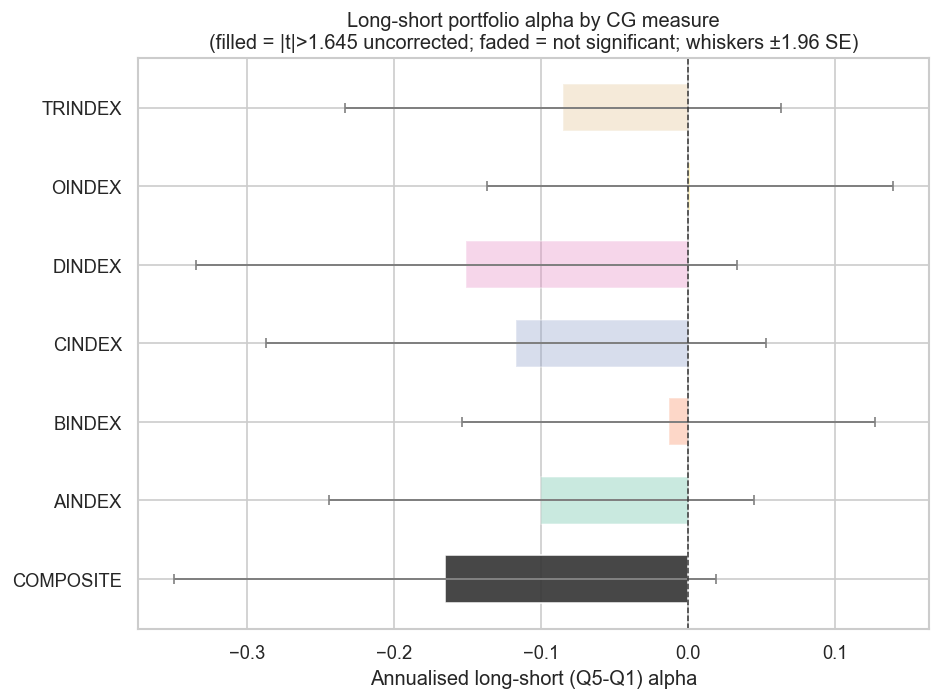

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
labels = ['COMPOSITE'] + CG_CATS
colors = ['#333333'] + list(plt.cm.Set2(np.linspace(0, 0.8, len(CG_CATS))))
ls_rows = factor_results[factor_results['Portfolio'] == 'LS'].set_index('Family').loc[labels]

for i, (lab, color) in enumerate(zip(labels, colors)):
    row = ls_rows.loc[lab]
    se = row['ann_alpha'] / row['t_alpha'] if row['t_alpha'] != 0 else np.nan
    alpha_val = 0.9 if abs(row['t_alpha']) > 1.645 else 0.35  # ~p<.10 (uncorrected)
    ax.barh(i, row['ann_alpha'], xerr=abs(se) * 1.96, color=color, alpha=alpha_val,
            height=0.6, error_kw={'linewidth': 1.2, 'capsize': 3, 'ecolor': 'grey'})

ax.axvline(0, color='#333', lw=0.9, ls='--')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Annualised long-short (Q5-Q1) alpha')
ax.set_title('Long-short portfolio alpha by CG measure\n'
             '(filled = |t|>1.645 uncorrected; faded = not significant; whiskers ±1.96 SE)')
plt.tight_layout(); plt.show()

## 5 — Turnover

Fraction of Q1 (low CG) and Q5 (high CG) membership that changes at each annual rebalance,
composite only (sub-index turnover is available in `families` if needed — governance scores
are slow-moving per `07`'s temporal-persistence check, so turnover should be modest).

In [7]:
turnover_rows = []
for q in [1, N_QUINTILES]:
    turnover_rows += compute_turnover(families['COMPOSITE'][1], q)
turnover_df = pd.DataFrame(turnover_rows)
print(turnover_df.round(3).to_string(index=False))
print(f"\nMean turnover, Q1: {turnover_df[turnover_df['Quintile']==1]['Turnover'].mean():.1%}"
      f"   Q5: {turnover_df[turnover_df['Quintile']==N_QUINTILES]['Turnover'].mean():.1%}")

 Rebalance  Quintile  N_prev  N_kept  Turnover
2023->2024         1      40      31     0.225
2024->2025         1      48      42     0.125
2023->2024         5      40      34     0.150
2024->2025         5      47      38     0.191

Mean turnover, Q1: 17.5%   Q5: 17.1%


## 6 — Transaction-cost sensitivity

Pre- vs. post-cost long-short alpha, `TC_ROUNDTRIP` (30 bps) deducted once per annual
rebalance from the long-short leg.

In [8]:
tc_compare = (factor_results[factor_results['Portfolio'].isin(['LS', 'LS_tc'])]
             .pivot(index='Family', columns='Portfolio', values=['ann_alpha', 't_alpha'])
             .loc[['COMPOSITE'] + CG_CATS])
tc_compare.columns = ['alpha_pre_tc', 'alpha_post_tc', 't_pre_tc', 't_post_tc']
tc_compare['tc_drag_annualised'] = tc_compare['alpha_pre_tc'] - tc_compare['alpha_post_tc']
print(tc_compare.round(4).to_string())

           alpha_pre_tc  alpha_post_tc  t_pre_tc  t_post_tc  tc_drag_annualised
Family                                                                         
COMPOSITE       -0.1654        -0.1681   -1.7592    -1.7884              0.0027
AINDEX          -0.0996        -0.1023   -1.3499    -1.3914              0.0027
BINDEX          -0.0130        -0.0158   -0.1816    -0.2179              0.0027
CINDEX          -0.1168        -0.1195   -1.3468    -1.3789              0.0027
DINDEX          -0.1506        -0.1533   -1.6034    -1.6351              0.0027
OINDEX           0.0013        -0.0014    0.0191    -0.0196              0.0027
TRINDEX         -0.0852        -0.0879   -1.1259    -1.1694              0.0027


## 7 — Romano-Wolf across the six sub-index long-short alpha tests

A moving-block bootstrap (block = 6 months, preserves short-run serial correlation in
monthly returns unlike i.i.d. resampling) rather than the cluster/firm bootstrap used in
`10_event_study.ipynb` — this is a time-series test (T≈34 pooled months), not a
cross-section, so the resampling unit is different, but the stepdown logic is the same
Romano & Wolf (2005) procedure. The same block-start draws are applied to all six
sub-indices per bootstrap replication, since they share the same calendar months and
factor realisations. **COMPOSITE is reported as a reference row, not part of the corrected
family** (six sub-indices only), per the framing decision that it's a summary convenience.

In [9]:
def ols_alpha_t(y, X):
    n, k = X.shape
    if n <= k:
        return np.nan, np.nan
    XtX_inv = np.linalg.pinv(X.T @ X)
    beta = XtX_inv @ (X.T @ y)
    resid = y - X @ beta
    sigma2 = (resid @ resid) / (n - k)
    se = np.sqrt(np.diag(sigma2 * XtX_inv))
    return beta[0], (beta[0] / se[0] if se[0] > 0 else np.nan)


def moving_block_bootstrap_rw(hyp_arrays, T, B=RW_B, block_len=RW_BLOCK_LEN, seed=42):
    """hyp_arrays: dict {key: (y, X)} with y=excess LS return, X=[const, factors...], all
    aligned to the SAME T months. Same block draws applied across all hypotheses per rep."""
    rng = np.random.default_rng(seed)
    keys = list(hyp_arrays.keys())
    S = len(keys)
    t_orig = np.array([ols_alpha_t(*hyp_arrays[k])[1] for k in keys])

    n_blocks = int(np.ceil(T / block_len))
    boot_t = np.full((B, S), np.nan)
    for b in range(B):
        starts = rng.integers(0, T - block_len + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, s + block_len) for s in starts])[:T]
        for si, k in enumerate(keys):
            y, X = hyp_arrays[k]
            _, t_b = ols_alpha_t(y[idx], X[idx])
            boot_t[b, si] = t_b

    centered = boot_t - t_orig[None, :]
    order = np.argsort(-np.abs(t_orig))
    p_adj = np.empty(S)
    active = list(order)
    for k in range(S):
        sk = order[k]
        m = np.nanmax(np.abs(centered[:, active]), axis=1)
        p_adj[sk] = np.nanmean(m >= np.abs(t_orig[sk]))
        active.remove(sk)
    running = 0.0
    for k in range(S):
        sk = order[k]
        running = max(running, p_adj[sk])
        p_adj[sk] = running
    return pd.Series(t_orig, index=keys, name='t'), pd.Series(p_adj, index=keys, name='p_rw')


# Align all 6 sub-indices (LS leg) to their common set of factor-covered months
ls_merged = {cat: families[cat][0][['LS']].join(factors_m, how='inner') for cat in CG_CATS}
common_idx = None
for cat in CG_CATS:
    common_idx = ls_merged[cat].index if common_idx is None else common_idx.intersection(ls_merged[cat].index)
print(f'Common months across all 6 sub-index LS series: {len(common_idx)}')

hyp_arrays = {}
for cat in CG_CATS:
    d = ls_merged[cat].loc[common_idx]
    y = d['LS'].values.astype(float)
    X = np.column_stack([np.ones(len(d)), d[FACTOR_COLS].values]).astype(float)
    hyp_arrays[cat] = (y, X)

t_ls, p_rw_ls = moving_block_bootstrap_rw(hyp_arrays, T=len(common_idx))

rw_table = pd.DataFrame({'t': t_ls, 'p_rw': p_rw_ls})
rw_table['ann_alpha'] = [ols_alpha_t(*hyp_arrays[c])[0] * 12 for c in CG_CATS]
rw_table = rw_table[['ann_alpha', 't', 'p_rw']].sort_values('p_rw')
print(rw_table.round(4).to_string())

comp_row = ls_rows.loc['COMPOSITE']
print(f"\nCOMPOSITE (reference, not RW-corrected): ann_alpha={comp_row['ann_alpha']:.4f}  t={comp_row['t_alpha']:.3f}")
print(f"\nSurvive RW p<.10: {(rw_table['p_rw'] < 0.10).sum()} / {len(rw_table)}")

Common months across all 6 sub-index LS series: 34


         ann_alpha       t    p_rw
DINDEX     -0.1506 -1.6034  0.7420
AINDEX     -0.0996 -1.3499  0.8125
CINDEX     -0.1168 -1.3468  0.8125
TRINDEX    -0.0852 -1.1259  0.8125
BINDEX     -0.0130 -0.1816  0.9885
OINDEX      0.0013  0.0191  0.9960

COMPOSITE (reference, not RW-corrected): ann_alpha=-0.1654  t=-1.759

Survive RW p<.10: 0 / 6


## 8 — Robustness: Q4-only composite

Per the framing decision ("Annual CG composite = simple mean across four quarters of FY t.
Q4-only score as a robustness variant"), rebuilds the COMPOSITE quintile sort using only
each firm's Q4(Y-1) score instead of the 4-quarter mean, and compares long-short alpha.

In [10]:
q4_only_ret, q4_only_holdings = build_portfolio_family(cat=None, quarter='Q4')
q4_only_reg = factor_regression(q4_only_ret, 'COMPOSITE_Q4only')

compare_q4 = pd.concat([
    factor_results[(factor_results['Family'] == 'COMPOSITE') & (factor_results['Portfolio'] == 'LS')],
    q4_only_reg[q4_only_reg['Portfolio'] == 'LS'],
])[['Family', 'N_months', 'ann_alpha', 't_alpha', 'Sharpe', 'beta_MKT']]
print(compare_q4.round(4).to_string(index=False))

# Rank correlation between the two CG_t definitions, by formation year
for Y in FORMATION_YEARS:
    d_mean = families['COMPOSITE'][1][Y][['CG_t']].rename(columns={'CG_t': 'CG_t_mean'})
    d_q4 = q4_only_holdings[Y][['CG_t']].rename(columns={'CG_t': 'CG_t_q4'})
    both = d_mean.join(d_q4, how='inner')
    rho = both['CG_t_mean'].corr(both['CG_t_q4'], method='spearman')
    print(f'Y={Y}: Spearman r(mean-of-4Q, Q4-only) = {rho:.3f}  (N={len(both)})')

          Family  N_months  ann_alpha  t_alpha  Sharpe  beta_MKT
       COMPOSITE        34    -0.1654  -1.7592 -0.8391   -0.1980
COMPOSITE_Q4only        34    -0.1022  -1.1803 -0.7704   -0.1666
Y=2023: Spearman r(mean-of-4Q, Q4-only) = 0.963  (N=195)
Y=2024: Spearman r(mean-of-4Q, Q4-only) = 0.962  (N=236)
Y=2025: Spearman r(mean-of-4Q, Q4-only) = 0.962  (N=237)


## Summary and saved outputs

In [11]:
factor_results.to_csv(PROC / 'portfolio_factor_regressions.csv', index=False)
turnover_df.to_csv(PROC / 'portfolio_turnover.csv', index=False)
rw_table.reset_index().rename(columns={'index': 'Category'}).to_csv(
    PROC / 'portfolio_longshort_romano_wolf.csv', index=False)
tc_compare.reset_index().to_csv(PROC / 'portfolio_transaction_cost_sensitivity.csv', index=False)

print('=' * 68)
print('  PORTFOLIO SORT SUMMARY')
print('=' * 68)
print(f'\nFormation years: {FORMATION_YEARS}  |  Pooled months per family: {factor_results["N_months"].iloc[0]}')

print('\n[Long-short alpha, pre-cost, by CG measure]')
print(ls_rows[['ann_alpha', 't_alpha', 'Sharpe', 'IR']].round(4).to_string())

print('\n[Romano-Wolf across the 6 sub-index long-short tests]')
print(rw_table.round(4).to_string())
print(f'  Survive RW p<.10: {(rw_table["p_rw"] < 0.10).sum()} / {len(rw_table)}')

print('\n[Transaction-cost drag on long-short alpha]')
print(tc_compare[['alpha_pre_tc', 'alpha_post_tc', 'tc_drag_annualised']].round(4).to_string())

print('\n[Turnover — COMPOSITE]')
print(f"  Q1 mean: {turnover_df[turnover_df['Quintile']==1]['Turnover'].mean():.1%}"
      f"   Q5 mean: {turnover_df[turnover_df['Quintile']==N_QUINTILES]['Turnover'].mean():.1%}")

print('\n[Q4-only robustness — COMPOSITE long-short]')
print(compare_q4.round(4).to_string(index=False))

print('\nSaved:')
for f in ['portfolio_factor_regressions.csv', 'portfolio_turnover.csv',
          'portfolio_longshort_romano_wolf.csv', 'portfolio_transaction_cost_sensitivity.csv']:
    print(f'  -> data/processed/{f}')
print('=' * 68)

  PORTFOLIO SORT SUMMARY

Formation years: [2023, 2024, 2025]  |  Pooled months per family: 34

[Long-short alpha, pre-cost, by CG measure]
           ann_alpha  t_alpha  Sharpe      IR
Family                                       
COMPOSITE    -0.1654  -1.7592 -0.8391 -1.2886
AINDEX       -0.0996  -1.3499 -0.3874 -0.9888
BINDEX       -0.0130  -0.1816 -0.1455 -0.1330
CINDEX       -0.1168  -1.3468 -0.7557 -0.9865
DINDEX       -0.1506  -1.6034 -0.6408 -1.1745
OINDEX        0.0013   0.0191 -0.0028  0.0140
TRINDEX      -0.0852  -1.1259 -1.1692 -0.8247

[Romano-Wolf across the 6 sub-index long-short tests]
         ann_alpha       t    p_rw
DINDEX     -0.1506 -1.6034  0.7420
AINDEX     -0.0996 -1.3499  0.8125
CINDEX     -0.1168 -1.3468  0.8125
TRINDEX    -0.0852 -1.1259  0.8125
BINDEX     -0.0130 -0.1816  0.9885
OINDEX      0.0013  0.0191  0.9960
  Survive RW p<.10: 0 / 6

[Transaction-cost drag on long-short alpha]
           alpha_pre_tc  alpha_post_tc  tc_drag_annualised
Family          

## 9 — Corrected primary spec: DINDEX excluded

Same Phase-2 fix as `09_regression.ipynb` Section 10 / `10_event_study.ipynb` Section 8 —
DINDEX's D2-D5 components fail LLM scoring on 61-67% of observations, dropped as
non-estimable. No industry FE exists in this notebook (quintile sorts, not a panel
regression), so Fix 2 doesn't apply here. `families[cat]` for every sub-index (including
DINDEX) was already built in §3/§4 above — nothing there is rebuilt; this section only
restricts the Romano-Wolf long-short family to the 5 primary sub-indices. `COMPOSITE`
remains, as originally framed in §7, a reference row outside the corrected family (still
its original 6-index average — not re-based here, since it was never part of the
RW-corrected family to begin with).

In [12]:
CG_CATS_PRIMARY = [c for c in CG_CATS if c != 'DINDEX']
print(f'CG_CATS_PRIMARY: {CG_CATS_PRIMARY}')

hyp_arrays_primary = {cat: hyp_arrays[cat] for cat in CG_CATS_PRIMARY}
t_ls_primary, p_rw_ls_primary = moving_block_bootstrap_rw(hyp_arrays_primary, T=len(common_idx))

rw_table_primary = pd.DataFrame({'t': t_ls_primary, 'p_rw': p_rw_ls_primary})
rw_table_primary['ann_alpha'] = [ols_alpha_t(*hyp_arrays_primary[c])[0] * 12 for c in CG_CATS_PRIMARY]
rw_table_primary = rw_table_primary[['ann_alpha', 't', 'p_rw']].sort_values('p_rw')
print(rw_table_primary.round(4).to_string())
print(f"\nSurvive RW p<.10: {(rw_table_primary['p_rw'] < 0.10).sum()} / {len(rw_table_primary)}")
print(f"(vs original 6-index family: {(rw_table['p_rw'] < 0.10).sum()} / {len(rw_table)})")

CG_CATS_PRIMARY: ['AINDEX', 'BINDEX', 'CINDEX', 'OINDEX', 'TRINDEX']


         ann_alpha       t    p_rw
AINDEX     -0.0996 -1.3499  0.8125
CINDEX     -0.1168 -1.3468  0.8125
TRINDEX    -0.0852 -1.1259  0.8125
BINDEX     -0.0130 -0.1816  0.9885
OINDEX      0.0013  0.0191  0.9960

Survive RW p<.10: 0 / 5
(vs original 6-index family: 0 / 6)


### 9.1 — Save outputs

Distinct filename — `portfolio_longshort_romano_wolf.csv` (original 6-index family) is
not overwritten.

In [13]:
rw_table_primary.reset_index().rename(columns={'index': 'Category'}).to_csv(
    PROC / 'portfolio_longshort_romano_wolf_primary.csv', index=False)
print('Saved -> data/processed/portfolio_longshort_romano_wolf_primary.csv')

print('=' * 68)
print('  SECTION 9 SUMMARY — DINDEX EXCLUDED')
print('=' * 68)
print(f'Family: {len(rw_table_primary)} long-short tests (5 sub-indices), vs 6 in the original family')
print(f"Survive RW p<.10: {(rw_table_primary['p_rw'] < 0.10).sum()} / {len(rw_table_primary)}")
sig = rw_table_primary[rw_table_primary['p_rw'] < 0.10]
print(sig.round(4).to_string() if len(sig) else '(none)')
print('=' * 68)

Saved -> data/processed/portfolio_longshort_romano_wolf_primary.csv
  SECTION 9 SUMMARY — DINDEX EXCLUDED
Family: 5 long-short tests (5 sub-indices), vs 6 in the original family
Survive RW p<.10: 0 / 5
(none)
